###NASA Earth Exchange Global Daily Downscaled Climate Projections
In this workflow, we are going to work with NASA Earth Exchange Global Daily Downscaled Climate Projections (NEX-GDDP-CMIP6). The data are located on Google Earth Engine, among other places.
https://developers.google.com/earth-engine/datasets/catalog/NASA_GDDP-CMIP6

For GEE, you need to navigate to https://earthengine.google.com/
1. Click on "Get Started" at the top left.
2. Click "Register a Noncommercial or Commercial Cloud Project"
3. Select "Unpaid usage":
  - Project Type = "Academia & Research".
  - Click "NEXT"
4. Choose "Create a new Google Cloud Project":
  - Organization: unive.it
  - Project-ID = some name
  - Project Name = make blank. Mine is 'ee-jeremypal'
  - Click "CONTINUE WITH REGISTRATION"
5. Continue with remaining prompts

In [1]:
# COLAB ONLY:  Install required modules
#!pip install xarray geemap rasterio cartopy contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.3 MB/s eta 0:00:00


In [17]:
import xarray as xr
import math
import pandas as pd
import geemap
import ee
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx
import datetime

# NASA GDDP-CMIP6

# Specify Surface Variable
variable = 'tas'
variables = [
    'hurs',   # [%] Relative humidity. Not present in 'BCC-CSM2-MR', 'NESM3', 'KIOST-ESM' (only for 'ssp245' in 2058)
    'huss',   # [Mass fraction] Specific humidity. Not present in 'IPSL-CM6A-LR', 'MIROC6', 'NESM3'
    'pr',     # [kg/m2/s] Precipitation
    'rlds',   # [W/m2] Surface downwelling longwave radiation
    'rsds',   # [W/m2] Surface downwelling shortwave radiation
    'sfcWind',# [m/s] Near-surface wind speed
    'tas',    # [K] Air temperature. Not present in: 'NorESM2-LM' (only for 'ssp585' in 2096)
    'tasmin', # [K] Daily minimum air temperature. Not present in 'CESM2', 'CESM2-WACCM', 'IITM-ESM', 'TaiESM1' (only for 'ssp585' in 2093)
    'tasmax'  # [K] Daily maximum air temperature. Not present in 'CESM2', 'CESM2-WACCM', 'IITM-ESM'
]

# Specify historical and scenario years
# - Historical years must be between 1950 and 2014
# - Scenario years must be between 2015 and 2100
year1_hist, year2_hist = 1985, 2014
year1_scen, year2_scen = 2071, 2100

# Specify scenario
scenarios = ['ssp245', 'ssp585']
scenario = 'ssp585'

# Specify climate model
models = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM',
          'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5',
          'EC-Earth3', 'EC-Earth3-Veg-LR', 'FGOALS-g3', 'GFDL-CM4', 'GFDL-ESM4',
          'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IITM-ESM',
          'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM',
          'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0',
          'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']
model = 'CMCC-ESM2'


if variable not in variables:
    raise ValueError(f'VARIABLE SELECTION ERROR: {variable} must be one of: {variables}')
if model not in models:
    raise ValueError(f'MODEL SELECTION ERROR: {model} must be one of: {model}')
if scenario not in scenarios:
    raise ValueError(f'SCENARIO SELECTION ERROR: {scenario} must be one of: {scenarios}')

if not (1950 <= year1_hist <= 2014 and 1950 <= year2_hist <= 2014 and
        2015 <= year1_scen <= 2100 and 2015 <= year2_scen <= 2100 and
        year1_hist < year2_hist and year1_scen < year2_scen):
    raise ValueError('YEAR SELECTION ERROR:'
        f'  Historical years must be between 1950 and 2014: {year1_hist} {year2_hist}'
        f'  Scenario years must be between 2015 and 2100: {year1_scen} {year2_scen}'
         '  The first year must be less than the second for both historical and scenario data.')
# Location coordinates, e.g., city center
#   South and north should be negative
lat_loc, lon_loc = 45.44, 12.32

# Define region bounds
#   A good way to figure this out is from https://geojson.io
#     - Draw a rectangle over a region of at least 2 x 2 degrees
#     – Round bounds to nearest 0.25 degrees
lat_min, lat_max = 43.5, 47.5
lon_min, lon_max = 10.5, 14.5

print('Modules loaded and parameters set')

Modules loaded and parameters set


### Authenticate and initialize GEE

In [5]:
#   If EE gives problems run the below command and follow browser steps
!earthengine authenticate --force

ee.Authenticate()
ee.Initialize()

E0000 00:00:1745589450.089717   10293 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745589450.097035   10293 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Authenticate: Limited support in Colab. Use ee.Authenticate() or --auth_mode=notebook instead.
To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=KCvQk09j3Z7l3bIYfi14k-flmC_U63gQWVnBGyYpXVo&tc=oznhFFVJVI4WSlmr8fnpu1mU3XyUywKYgYB

Load Climate Dataset

In [18]:
climate_dataset = ee.ImageCollection("NASA/GDDP-CMIP6").select(variable)
print(f'Variable "{variable}" Loaded')

# Determine dataset scale in meters
sample_image = ee.Image(climate_dataset.first())  # Any image from the dataset
scale = sample_image.projection().nominalScale().getInfo()
print(f'Dataset scale is {scale} m')

Variable "tas" Loaded
Dataset scale is 27829.87269831839 m


### Define bounding box and center for GEE

In [23]:
# expand map extents by half a grid point in each direction
ddeg_shift = scale/111000/2
lat_min, lat_max = lat_min - ddeg_shift, lat_max + ddeg_shift
lon_min, lon_max = lon_min - ddeg_shift, lon_max + ddeg_shift

# Bounding box
gee_bbox = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])

# Map center
lat_center = (lat_min + lat_max) / 2
lon_center = (lon_min + lon_max) / 2
map_center=[lat_center, lon_center]

print(f'Bounding box')
print(f'  Latitudes {round(lat_min, 2)} to {round(lat_max, 2)}')
print(f'  Longitudes {round(lon_min, 2)} to {round(lon_max, 2)}')


Bounding box
  Latitudes 43.0 to 48.0
  Longitudes 10.0 to 15.0


### Load NASA GDDP-CMIP6 dataset for given variable, model and scenario.


In [42]:
# Define time periods for comparison
var_ee_hist = (
    climate_dataset
    .filter(ee.Filter.date(f"{year1_hist}-01-01", f"{year2_hist}-12-31"))
    .filter(ee.Filter.eq("model", model))
    .filter(ee.Filter.eq("scenario", "historical"))
    .mean()
    .clip(gee_bbox)
)
var_ee_scen = (
    climate_dataset
    .filter(ee.Filter.date(f"{year1_scen}-01-01", f"{year2_scen}-12-31"))
    .filter(ee.Filter.eq("model", model))
    .filter(ee.Filter.eq("scenario", scenario))
    .mean()
    .clip(gee_bbox)
)

print('Filters set')

Filters set


###Perform any necessary unit converstions and set variable units

In [43]:
# Convert from Kelvin to Celsius
if variable[:3] == "tas":
    var_ee_hist = var_ee_hist.subtract(273.15)
    var_ee_scen = var_ee_scen.subtract(273.15)
    var_units = '°C'
# Convert precipitation rate (kg/m²/s) to daily total (mm/day)
elif variable == "pr":
    var_ee_hist = var_ee_hist.multiply(86400)
    var_scen = var_ee_scen.multiply(86400)
    var_units = 'mm/hr'

### View the data
You will likely need to adjust the colar scale ranges "min" and "max" based on the location

In [57]:
# Visualization parameters
temp_vis = {
    "min": 0,  # Adjust based on the dataset
    "max": 24,
    "palette": ["blue", "cyan", "yellow", "orange", "red"],
}

# Create map and add layer slider
m = geemap.Map(center=map_center, zoom=7)

# Left: Historical temperature + cropland
var_left = geemap.ee_tile_layer(
    var_ee_hist, temp_vis, f"Historical ({year1_hist}-{year2_hist})",
    opacity=0.7
    )

# Right: SSP585 temperature + cropland
var_right = geemap.ee_tile_layer(
    var_ee_scen, temp_vis, f"{scenario.upper()} ({year1_scen}-{year2_scen})",
    opacity=0.7
    )

# Create split map
m.split_map(var_left, var_right)

# Add colorbar
m.add_colorbar(temp_vis, label="Average Near-Surface Air Temperature (C)",
               layer_name="Historical ({year1_hist}-{year2_hist})")


# Display the map
m

Map(center=[45.5, 12.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

### Convert the temperature data to xarray
To perform more advanced data processing, it is often necessary to convert GEE data to xarray.

In [45]:
ds_hist = geemap.ee_to_xarray(
    dataset = var_ee_hist,
    geometry=gee_bbox,
    scale=0.25,
    crs="EPSG:4326"
)

ds_scen = geemap.ee_to_xarray(
    dataset = var_ee_scen,
    geometry=gee_bbox,
    scale=0.25,
    crs="EPSG:4326"
)

###Check the data

In [30]:
print(ds_hist)
print(ds_scen)

<xarray.Dataset> Size: 2kB
Dimensions:  (time: 1, lon: 20, lat: 20)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 160B 10.12 10.37 10.62 10.87 ... 14.37 14.62 14.87
  * lat      (lat) float64 160B 43.12 43.37 43.62 43.87 ... 47.37 47.62 47.87
Data variables:
    tas      (time, lon, lat) float32 2kB ...
Attributes:
    crs:      EPSG:4326
<xarray.Dataset> Size: 2kB
Dimensions:  (time: 1, lon: 20, lat: 20)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 160B 10.12 10.37 10.62 10.87 ... 14.37 14.62 14.87
  * lat      (lat) float64 160B 43.12 43.37 43.62 43.87 ... 47.37 47.62 47.87
Data variables:
    tas      (time, lon, lat) float32 2kB ...
Attributes:
    crs:      EPSG:4326


### Compute difference (Scenario - Historical)



In [46]:
var_hist, var_scen = ds_hist[variable], ds_scen[variable]
var_hist = var_hist.squeeze(dim='time').transpose("lat", "lon")
var_scen = var_scen.squeeze(dim='time').transpose("lat", "lon")
var_diff = var_scen - var_hist

### Check the results

In [47]:
print(var_hist)
print(var_scen)
print(var_diff )

<xarray.DataArray 'tas' (lat: 20, lon: 20)> Size: 2kB
[400 values with dtype=float32]
Coordinates:
    time     int64 8B 0
  * lon      (lon) float64 160B 10.12 10.37 10.62 10.87 ... 14.37 14.62 14.87
  * lat      (lat) float64 160B 43.12 43.37 43.62 43.87 ... 47.37 47.62 47.87
Attributes:
    id:             tas
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    dimensions:     [7, 7]
    origin:         [9, 42]
    crs:            EPSG:4326
    crs_transform:  [1, 0, 0, 0, 1, 0]
<xarray.DataArray 'tas' (lat: 20, lon: 20)> Size: 2kB
[400 values with dtype=float32]
Coordinates:
    time     int64 8B 0
  * lon      (lon) float64 160B 10.12 10.37 10.62 10.87 ... 14.37 14.62 14.87
  * lat      (lat) float64 160B 43.12 43.37 43.62 43.87 ... 47.37 47.62 47.87
Attributes:
    id:             tas
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    dimensions:     [7, 7]
    origin:         [9, 42]
    crs:            EPSG:4326
    crs_transform:  [1, 0, 0, 0

#Generate Historical and Future minus Historical Maps
You will most likely need to adjust the color bar ranges vmin_hist, vmax_hist, vmin_diff and vmax_diff.

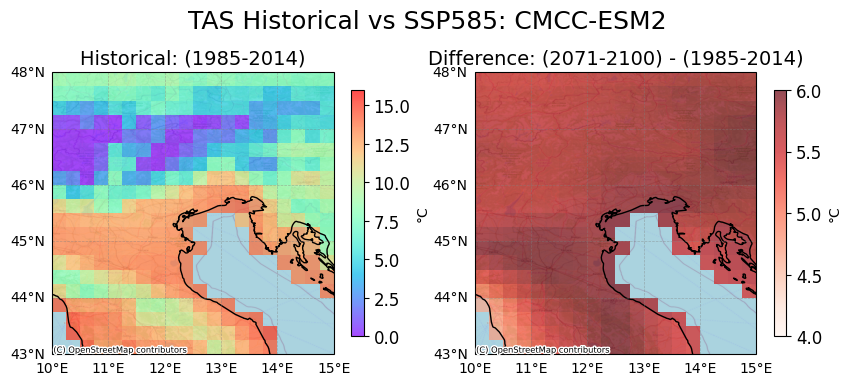

In [52]:
# Define colormap ranges
vmin_hist, vmax_hist = 0.0, 16.0 # Adjust as needed for the historical plot
vmin_diff, vmax_diff = 4, 6  # Adjust as needed for the difference plot

# Create the figure with two panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8),
                               subplot_kw={"projection": ccrs.PlateCarree()})

# Map extents
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plot the historical data on the left
pcm_hist = var_hist.plot(ax=ax1, cmap="rainbow", alpha=0.7,
                         vmin=vmin_hist, vmax=vmax_hist, add_colorbar=False)

# Add coastlines and basemap to the historical panel
ax1.add_feature(cfeature.COASTLINE)
ctx.add_basemap(ax1, crs=ds_hist.crs,
                source=ctx.providers.OpenStreetMap.Mapnik, attribution_size=6,
                alpha=1)

# Add gridlines to the historical panel
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5,
                    linestyle="--")
gl1.top_labels = False
gl1.right_labels = False

# Add colorbar for historical panel
cbar_hist = fig.colorbar(pcm_hist, ax=ax1, location="right", shrink=0.4, label="°C")
cbar_hist.ax.tick_params(labelsize=12)
ax1.set_title(f"Historical: ({year1_hist}-{year2_hist})", fontsize=14)

# Plot the difference (scenario minus historical) on the right
pcm_diff = var_diff.plot(ax=ax2, cmap="Reds", alpha=0.7,
                         vmin=vmin_diff, vmax=vmax_diff, add_colorbar=False)

# Add coastlines and basemap to the difference panel
ax2.add_feature(cfeature.COASTLINE)
ctx.add_basemap(ax2, crs=ds_hist.crs,
                source=ctx.providers.OpenStreetMap.Mapnik, attribution_size=6,
                alpha=1)

# Add gridlines to the difference panel
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5,
                    linestyle="--")
gl2.top_labels = False
gl2.right_labels = False

# Add colorbar for difference panel
cbar_diff = fig.colorbar(pcm_diff, ax=ax2, location="right", shrink=0.4,
                         label=var_units)
cbar_diff.ax.tick_params(labelsize=12)
ax2.set_title(f"Difference: ({year1_scen}-{year2_scen}) - ({year1_hist}-{year2_hist})", fontsize=14)

plt.suptitle(f"{variable.upper()} Historical vs {scenario.upper()}: {model}", fontsize=18, y=0.75)

plt.savefig(f"{variable.upper()}_{scenario.upper()}_{model}_{scenario}{year1_scen}-{year2_scen}_hist{year1_hist}-{year2_hist}.png", bbox_inches="tight")

plt.show()

## Annual Average Time Series Plots
Here were are going to load monthly NASA data for nearest gridpoint to defined location for create a time series. Note that the full time series for both the historical and scenario datasets will be loaded.

In [55]:
# Target point and parameters
target_point = ee.Geometry.Point(lon_loc, lat_loc)

# Function to extract point value
def extract_value(img):
    value = img.sample(target_point, scale=scale, dropNulls=False).first().get(variable)
    return img.set({
        'time': img.date().format('YYYY-MM-dd'),
        'value': value  # Store pixel value as a property
    })

# Filter historical data
collection_hist = (
    climate_dataset
    .filter(ee.Filter.eq("model", model))
    .filter(ee.Filter.eq("scenario", "historical"))
    .filterBounds(target_point)
    .map(extract_value)  # Use the function to extract values
)

# Filter scenario data
collection_scen = (
    climate_dataset
    .filter(ee.Filter.eq("model", model))
    .filter(ee.Filter.eq("scenario", scenario))
    .filterBounds(target_point)
    .map(extract_value)  # Use the function to extract values
)

print('Filters set')

Filters set


### Extract values based on filters

In [56]:
# Function to extract values
def get_values(collection):
    # Extract the 'time' and 'value' properties
    result = collection.reduceColumns(
        reducer=ee.Reducer.toList(2),
        selectors=['time', 'value']  # Use 'value', not the variable name!
    ).get('list')
    data = result.getInfo()
    return list(zip(*data)) if data else ([], [])

print('This step can take some time. Be patient')
# Get data
print('  Extracting historical data')
times_hist, vals_hist = get_values(collection_hist)
print('  Extracting scenario data')
times_scen, vals_scen = get_values(collection_scen)
print('\nDone')

###Check that data was loaded

In [58]:
print(f"Historical: {len(times_hist)} times, {len(vals_hist)} values")
print(vals_hist)
print(f"Scenario: {len(times_scen)} times, {len(vals_scen)} values")
print(times_hist)

Historical: 23741 times, 23741 values
(278.3468322753906, 276.90374755859375, 277.4655456542969, 279.66632080078125, 277.28302001953125, 275.4272155761719, 279.5003662109375, 280.0124816894531, 277.1044921875, 275.45916748046875, 279.44207763671875, 279.91448974609375, 279.54241943359375, 276.9435119628906, 276.9026794433594, 276.14544677734375, 275.8759460449219, 275.73297119140625, 272.6387939453125, 270.81353759765625, 269.2154541015625, 269.71234130859375, 272.1927795410156, 272.72064208984375, 273.52911376953125, 274.44317626953125, 273.17144775390625, 273.0196533203125, 274.18231201171875, 273.43133544921875, 274.225830078125, 275.7587890625, 275.11712646484375, 275.021728515625, 277.59808349609375, 280.03497314453125, 279.9273681640625, 280.85748291015625, 279.8910217285156, 278.876708984375, 279.5555419921875, 280.5107421875, 279.6127624511719, 280.28802490234375, 280.17547607421875, 280.4024658203125, 280.7708740234375, 277.49407958984375, 276.7845764160156, 277.0129699707031,

###Convert Earth Engine data to a dataframe
Dataframes are a two-dimensional data organized with rows and columns (similar to spreadsheets). Pandas is Python tool/module used to process dataframes.

In [61]:
# Convert EE time strings to datetime objects
df_mon_hist = pd.DataFrame({
    "time": pd.to_datetime(times_hist),  # Direct conversion from string
    "Historical": vals_hist
})

df_mon_scen = pd.DataFrame({
    "time": pd.to_datetime(times_scen),
    scenario: vals_scen
})

# Handle null values (if any)
df_mon_hist = df_mon_hist.dropna()
df_mon_scen = df_mon_scen.dropna()

# Ensure datetime format (redundant but safe)
df_mon_hist['time'] = pd.to_datetime(df_mon_hist['time'])
df_mon_scen['time'] = pd.to_datetime(df_mon_scen['time'])

print('GEE Data Converted to DataFrame')

GEE Data Converted to DataFrame


###Perform any necessary unit converstions and set variable units

In [62]:
# Unit conversions
if variable == 'tas':
    # Convert Kelvin to Celsius
    df_mon_hist['Historical'] = df_mon_hist['Historical'] - 273.15
    df_mon_scen[scenario] = df_mon_scen[scenario] - 273.15
    var_units = '°C'
elif variable == 'pr':
    # Convert kg/m²/s to mm/day (1 kg/m² = 1 mm, 86400 seconds/day)
    df_mon_hist['Historical'] = df_mon_hist['Historical'] * 86400
    df_mon_scen[scenario] = df_mon_scen[scenario] * 86400
    var_units = 'mm/hr'

###Check the data

In [63]:
print(df_mon_hist)
print(df_mon_scen)

            time  Historical
0     1950-01-01    5.196832
1     1950-01-02    3.753748
2     1950-01-03    4.315546
3     1950-01-04    6.516321
4     1950-01-05    4.133020
...          ...         ...
23736 2014-12-27    1.026849
23737 2014-12-28   -1.303656
23738 2014-12-29   -1.711157
23739 2014-12-30    2.186426
23740 2014-12-31    0.898523

[23741 rows x 2 columns]
            time     ssp585
0     2015-01-01   3.445642
1     2015-01-02   1.063287
2     2015-01-03  -0.099829
3     2015-01-04   2.825159
4     2015-01-05   2.541406
...          ...        ...
31406 2100-12-27  10.109430
31407 2100-12-28  10.352625
31408 2100-12-29   9.464197
31409 2100-12-30   5.802515
31410 2100-12-31   5.090295

[31411 rows x 2 columns]


### Annual averages

In [64]:
# Extract the year from the time column
df_mon_hist['year'] = df_mon_hist['time'].dt.year
df_mon_scen['year'] = df_mon_scen['time'].dt.year

# Compute annual means for each DataFrame
df_ann_hist = df_mon_hist.groupby('year').agg({'Historical': 'mean'}).reset_index()
df_ann_scen = df_mon_scen.groupby('year').agg({scenario: 'mean'}).reset_index()

###Check the data

In [65]:
print(df_ann_hist)
print(df_ann_scen)

    year  Historical
0   1950   13.879699
1   1951   12.511965
2   1952   11.934393
3   1953   12.428043
4   1954   12.432873
..   ...         ...
60  2010   14.334883
61  2011   12.720177
62  2012   12.874303
63  2013   13.890489
64  2014   14.049281

[65 rows x 2 columns]
    year     ssp585
0   2015  14.216111
1   2016  13.761910
2   2017  13.116581
3   2018  14.036707
4   2019  13.911738
..   ...        ...
81  2096  20.563361
82  2097  19.805230
83  2098  20.270789
84  2099  20.398486
85  2100  19.725955

[86 rows x 2 columns]


###Plot the time series

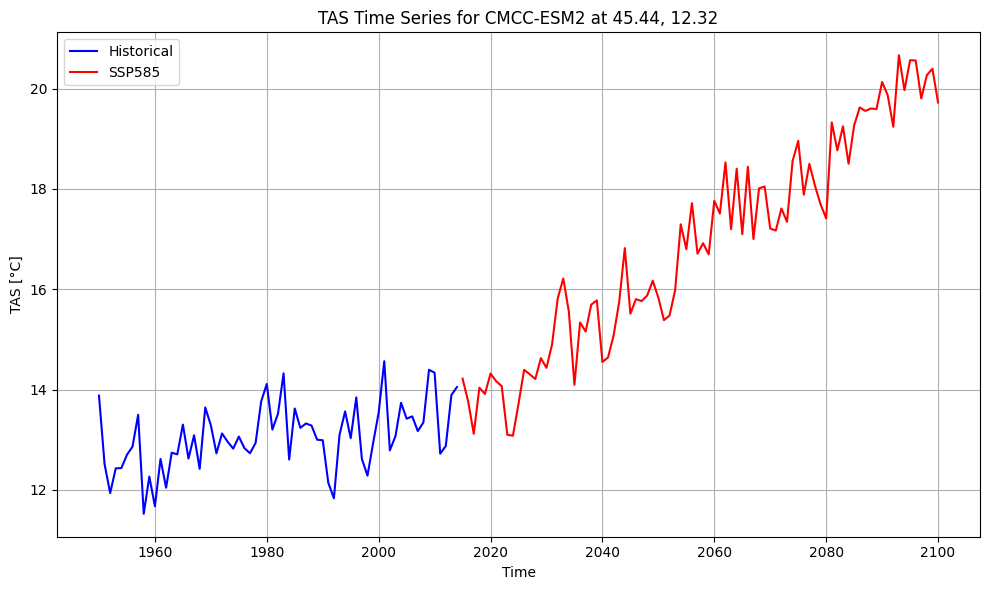

In [66]:
import matplotlib.pyplot as plt

# Plot each DataFrame independently
plt.figure(figsize=(10, 6))

# Plot df_mon_hist
plt.plot(df_ann_hist["year"], df_ann_hist["Historical"], label="Historical", color="blue")

# Plot df_mon_scen
plt.plot(df_ann_scen["year"], df_ann_scen[scenario], label=scenario.upper(), color="red")

# Add labels, title, and legend
plt.xlabel("Time")
plt.ylabel(f"{variable.upper()} [°C]")
plt.title(f"{variable.upper()} Time Series for {model} at {lat_loc}, {lon_loc}")
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()